# Эффективность каналов привлечения и воронка продаж

* Выгружаем данные

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
data = pd.read_csv(r'C:/Users/днс/Downloads/case.csv')

In [3]:
data.head()

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads


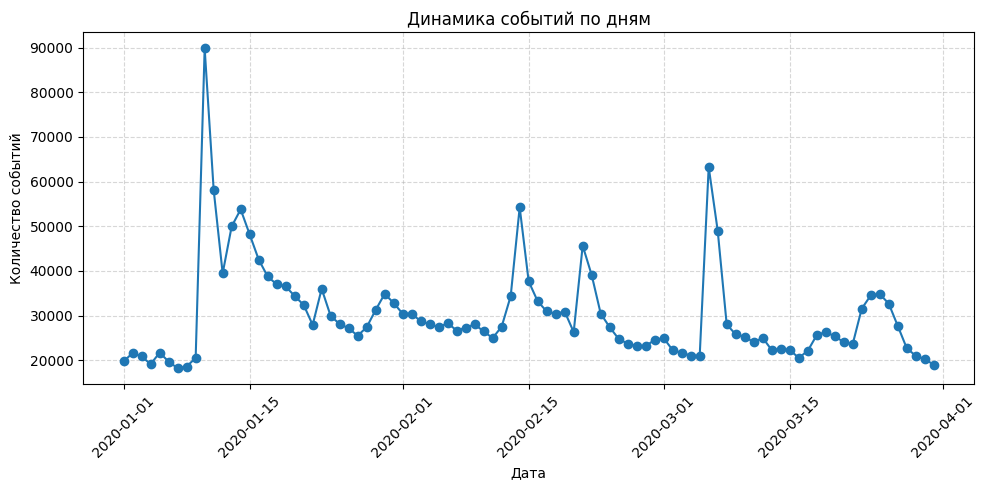

День с наибольшим количеством событий: 10.01.2020


In [4]:
data['date'] = pd.to_datetime(data['date'])

# Агрегируем количество событий по дням
daily_counts = data.groupby('date').size().reset_index(name='events_count')

# Строим график динамики
plt.figure(figsize=(10, 5))
plt.plot(daily_counts['date'], daily_counts['events_count'], marker='o', linestyle='-')
plt.title('Динамика событий по дням')
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Находим день с наибольшим количеством событий
max_row = daily_counts.loc[daily_counts['events_count'].idxmax()]
max_date_str = max_row['date'].strftime('%d.%m.%Y')

print(f"День с наибольшим количеством событий: {max_date_str}")

In [5]:
data['event'].value_counts()

event
app_start      748705
search         708639
choose_item    538669
tap_basket     377665
app_install    154597
purchase       141383
register        78310
Name: count, dtype: int64

* Определяем установку и группы

In [6]:
installs = data[data['event'] == 'app_install']
data['install_date'] = data['device_id'].map(installs.set_index('device_id')['date'])
def new_column(date1,date2,value):
    if date1 == date2:
        return value
data['install_group'] = data.apply(lambda x: new_column(date1 = x['date'], date2 = x['install_date'], value = 'Установили в этот же день'), axis=1)
data['install_group'] = data['install_group'].fillna('Остальные')
data[data['event'] == 'app_start']['install_group'].value_counts()

install_group
Остальные                    594108
Установили в этот же день    154597
Name: count, dtype: int64

In [7]:
data[data['install_date'].dt.date == pd.to_datetime('2020-03-31').date()]['device_id'].nunique()

968

968 людей установили приложение 31 марта

In [8]:
opens_date = data[
    (data['event'] == 'app_start') &
    (data['date'].dt.date == pd.to_datetime('2020-02-14').date())]

share = opens_date['install_date'].notna().mean()
print(share * 100)

81.25777470628887


81% пользователей (у которых приложение уже было установлено) открыли приложение 14 февраля.

In [9]:
# Оставляем только открытия приложения

opens = data[data['event'] == 'app_start'].copy()

# Для каждого дня считаем количество открытий

total_opens = opens.groupby('date')['device_id'].count()

# Для каждого дня считаем открытия пользователей, которые установили приложение именно в этот день

installs_opens = opens[
    opens['install_date'].notna() &
    (opens['date'] == opens['install_date'])
].groupby('date')['device_id'].count()

# Считаем долю

share = (installs_opens / total_opens).sort_values(ascending=False)
share.head()

date
2020-01-01    0.805174
2020-01-02    0.616350
2020-01-10    0.611601
2020-01-03    0.466952
2020-01-14    0.399861
Name: device_id, dtype: float64

01.01.2020 доля трафиков была наибольшей

* Определим популярный канал

In [10]:
installs = data[
    (data['event'] == 'app_start') &
    (data['install_date'].notna()) &
    (data['date'] == data['install_date'])
]

installs.groupby('utm_source')['device_id'].nunique().sort_values(ascending=False)

utm_source
-                32460
yandex-direct    29368
google_ads       26286
vk_ads           23189
instagram_ads    20096
facebook_ads     13916
referal           9282
Name: device_id, dtype: int64

In [13]:
first_opens = data[data['event'] == 'app_start'].copy()
first_opens = first_opens.sort_values('date').drop_duplicates('device_id')
first_opens.groupby('utm_source')['device_id'].nunique().sort_values(ascending=False)

utm_source
-                41456
yandex-direct    34441
google_ads       31437
vk_ads           27905
instagram_ads    24818
facebook_ads     18844
referal          11983
Name: device_id, dtype: int64

Из Яндекса пришло больше всего пользователей и первых открытий было больше всего в этом приложении 

In [14]:
data['event'].value_counts()

event
app_start      748705
search         708639
choose_item    538669
tap_basket     377665
app_install    154597
purchase       141383
register        78310
Name: count, dtype: int64

* Анализ воронки

Зарегистрированные пользователи

In [15]:
registered_ids = data.loc[data['event'] == 'register','device_id'].unique()

registered = data[data['device_id'].isin(registered_ids)]

steps_registered = [
    'app_start',
    'search',
    'choose_item',
    'tap_basket',
    'register',
    'purchase'
]

counts_registered = []

for step in steps_registered:
    count = registered.loc[registered['event'] == step,'device_id'].nunique()
    counts_registered.append(count)

for i in range(1, len(steps_registered)):
    conversion = counts_registered[i] / counts_registered[i-1] * 100
    print(steps_registered[i],':',round(conversion, 2),'%')

search : 100.0 %
choose_item : 100.0 %
tap_basket : 100.0 %
register : 100.0 %
purchase : 90.51 %


Незарегистрированные пользователи

In [18]:
unregistered_ids = data.loc[~data['device_id'].isin(registered_ids),'device_id'].unique()

unregistered = data[data['device_id'].isin(unregistered_ids)]

steps_unregistered = [
    'app_start',
    'search',
    'choose_item',
    'tap_basket',
    'purchase'
]

counts_unregistered = []

for step in steps_unregistered:
    count = unregistered.loc[unregistered['event'] == step,'device_id'].nunique()
    counts_unregistered.append(count)

for i in range(1, len(steps_unregistered)):
    conversion = counts_unregistered[i] / counts_unregistered[i-1] * 100
    print(steps_unregistered[i],':',round(conversion, 2),'%')

search : 94.32 %
choose_item : 72.88 %
tap_basket : 60.87 %
purchase : 0.0 %


Конверсия в первую покупку

In [21]:
first_opens = data[data['event'] == 'app_start'].sort_values('date').drop_duplicates('device_id').groupby(['utm_source']).size().reset_index(name = 'users')
first_purchase = data[data['event'] == 'purchase'].sort_values('date').drop_duplicates('device_id').groupby(['utm_source']).size().reset_index(name = 'users')

stat = first_opens.merge(first_purchase, how = 'left', on = 'utm_source')
stat['CR to first purchase'] = stat['users_y']/stat['users_x']
stat

,utm_source,users_x,users_y,CR to first purchase
0,-,41456,14786,0.356667
1,facebook_ads,18844,7903,0.419391
2,google_ads,31437,10167,0.323409
3,instagram_ads,24818,9820,0.395681
4,referal,11983,5803,0.484269
5,vk_ads,27905,11460,0.410679
6,yandex-direct,34441,10936,0.317529


Первый чек

In [24]:
data[data['event'] == 'purchase'].sort_values(
    'date').drop_duplicates('device_id').groupby([
        'utm_source'])['purchase_sum'].agg([
            'mean','median']).sort_values('mean', ascending = False)

,mean,median
utm_source,,
yandex-direct,725.740719,392.5
vk_ads,716.480192,393.0
instagram_ads,716.201018,393.5
google_ads,700.920134,390.5
-,698.211078,398.5
referal,696.420128,395.5
facebook_ads,692.090029,389.0


Расходы на реферальную программу

In [28]:
data[data['event'] == 'purchase'].groupby(['utm_source'])['purchase_sum'].sum()

print('Яндекс: {} %'.format((13909563/10491707-1)*100))
print('Гугл: {} %'.format((12866891/10534878-1)*100))
print('Фейсбук: {} %'.format((12248920/8534878-1)*100))
print('Инстаграм: {} %'.format((14545448/8561626 -1)*100))
print('ВК: {} %'.format((16390632/9553531-1)*100))

data[data['event']=='purchase'].drop_duplicates('device_id')['utm_source'].value_counts()


Яндекс: 32.576738942480944 %
Гугл: 22.13611776045248 %
Фейсбук: 43.5160526020407 %
Инстаграм: 69.89118655731983 %
ВК: 71.56621986153601 %


utm_source
-                14786
vk_ads           11460
yandex-direct    10936
google_ads       10167
instagram_ads     9820
facebook_ads      7903
referal           5803
Name: count, dtype: int64

* Пользовательская аналитика

Самая активная когорта

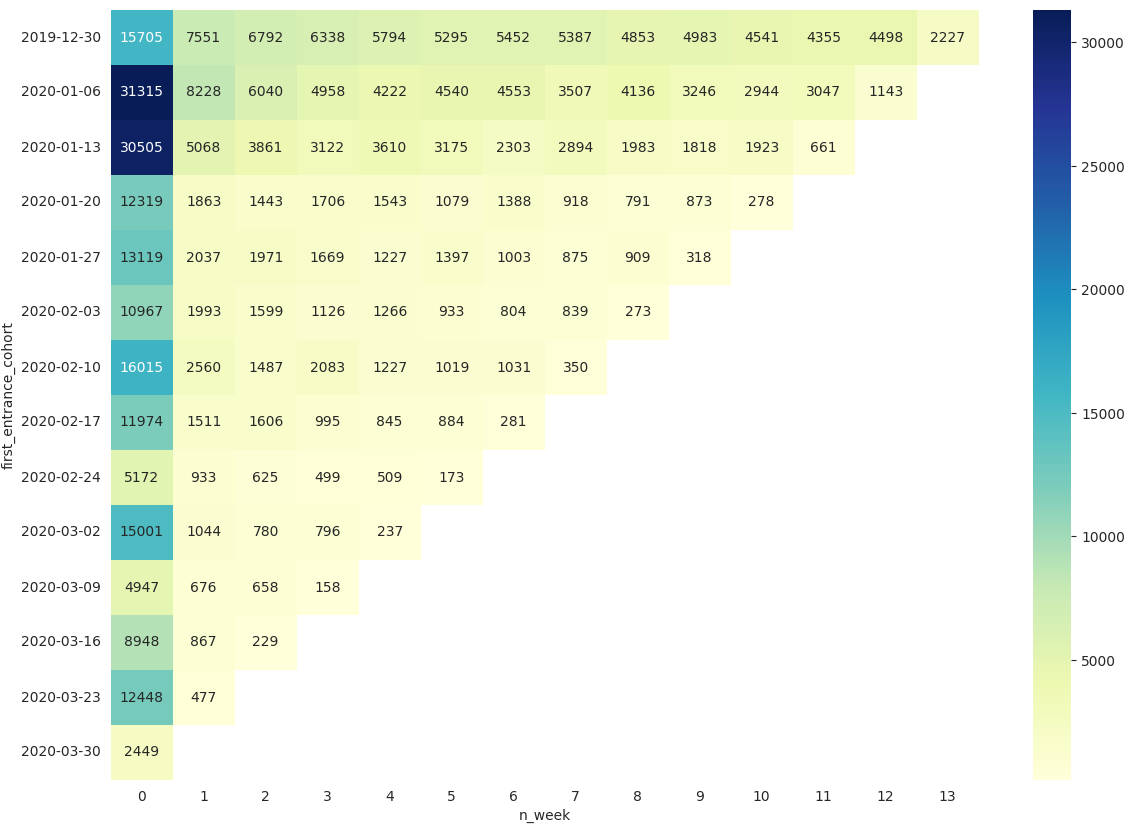

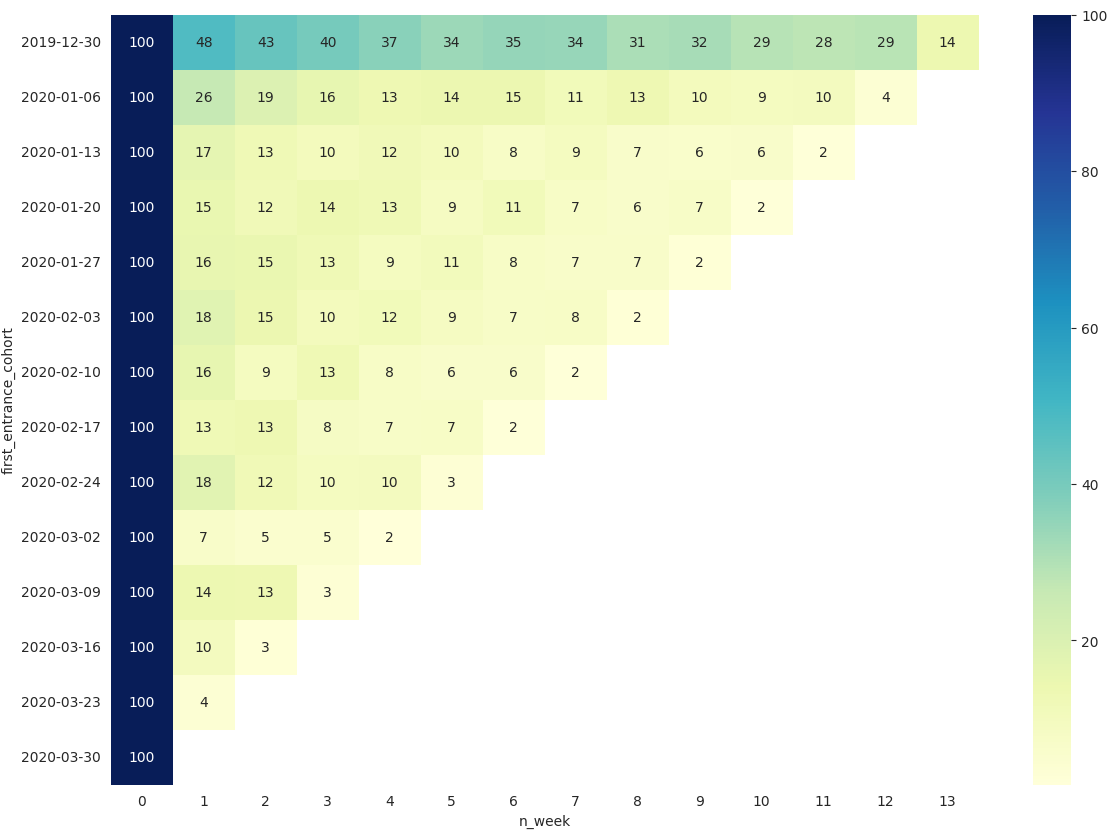

In [39]:
entrances = data[data['event'] == 'app_start'].sort_values('date').drop_duplicates('device_id')
data['first_entrance'] = data['device_id'].map(entrances.set_index('device_id')['date'])
data['first_entrance'] = pd.to_datetime(data['first_entrance'], format = '%Y-%m-%d')
data['first_entrance_cohort'] = data['first_entrance'].apply(lambda x: x + datetime.timedelta(days=-x.weekday(), weeks=0))
data['date'] = pd.to_datetime(data['date'], format = '%Y-%m-%d')
data['n_week'] = data['date'] - data['first_entrance_cohort']
data['n_week'] = data['n_week'].apply(lambda x: x.days // 7 )
data['first_entrance_cohort'] = data['first_entrance_cohort'].apply(lambda x: str(x)[:10])
viz = data.pivot_table(
                        index='first_entrance_cohort', 
                        columns='n_week', 
                        values='device_id', 
                        aggfunc=pd.Series.nunique)

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(14, 10))
    ax = sns.heatmap(viz, annot=True, fmt=".0f", cmap="YlGnBu");
    
viz = viz.apply(lambda x: x*100/viz[0])
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(14, 10))
    ax = sns.heatmap(viz, annot=True, fmt=".0f", cmap="YlGnBu");

30.12.2019 самая активная когорта. У неё активность больше, чем у остальных.

In [41]:
purchases = data[data['event'] == 'purchase'].sort_values('date').drop_duplicates('device_id')
data['first_purchase'] = data['device_id'].map(purchases.set_index('device_id')['date'])
data['first_purchase'] = pd.to_datetime(data['first_purchase'], format = '%Y-%m-%d')
df = data[-data['first_purchase'].isna()]
df['first_purchase_cohort'] = df['first_purchase'].apply(lambda x: x + datetime.timedelta(days=-x.weekday(), weeks=0))
df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d')
df['n_week'] = df['date'] - df['first_purchase_cohort']
df['n_week'] = df['n_week'].apply(lambda x: x.days // 7 )
df['first_purchase_cohort'] = df['first_purchase_cohort'].apply(lambda x: str(x)[:10])

df = df[df['event'] == 'purchase']
df.groupby('first_purchase_cohort')['purchase_sum'].sum().reset_index(name = 'LTV').sort_values('LTV', ascending = False)

C:\Users\днс\AppData\Local\Temp\ipykernel_13884\508006838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['first_purchase_cohort'] = df['first_purchase'].apply(lambda x: x + datetime.timedelta(days=-x.weekday(), weeks=0))
C:\Users\днс\AppData\Local\Temp\ipykernel_13884\508006838.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d')
C:\Users\днс\AppData\Local\Temp\ipykernel_13884\508006838.py:7: SettingWithCopyWarning: 
A value is trying to be

,first_purchase_cohort,LTV
1,2020-01-06,19787838.0
2,2020-01-13,18852452.0
0,2019-12-30,12320177.5
3,2020-01-20,9018049.5
4,2020-01-27,7432634.0
6,2020-02-10,6766314.0
5,2020-02-03,6305237.0
7,2020-02-17,5398837.5
9,2020-03-02,3629773.0
8,2020-02-24,3067633.5


06.01.2020 когорта принесла наибольший доход

C:\Users\днс\AppData\Local\Temp\ipykernel_13884\1845860755.py:1: FutureWarning: The provided callable <function median at 0x0000022C3307C310> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  viz = df.pivot_table(


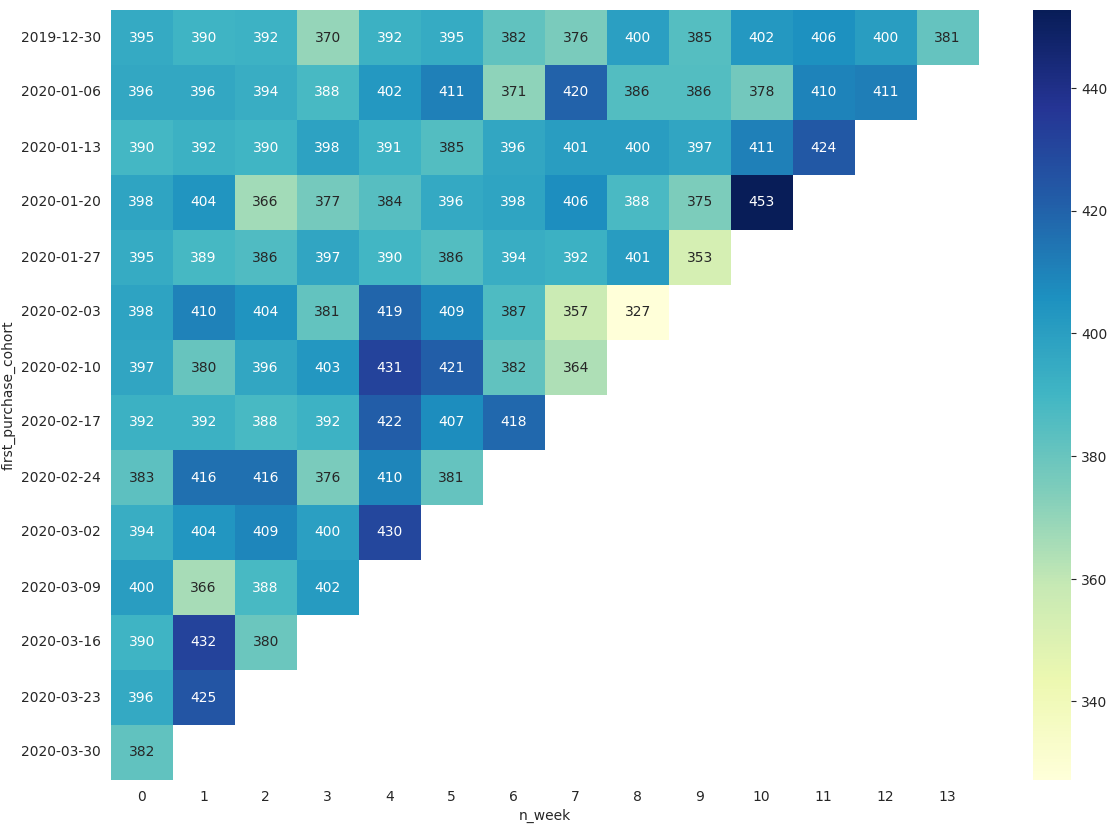

In [47]:
viz = df.pivot_table(
                        index='first_purchase_cohort', 
                        columns='n_week', 
                        values='purchase_sum', 
                        aggfunc=np.median)

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(14, 10))
    ax = sns.heatmap(viz, annot=True, fmt=".0f", cmap="YlGnBu");

Медианный чек на неделе первой покупки выше у когорты от 9 марта (=400 рублей).

C:\Users\днс\AppData\Local\Temp\ipykernel_13884\1414994926.py:1: FutureWarning: The provided callable <function median at 0x0000022C3307C310> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  viz = df.pivot_table(


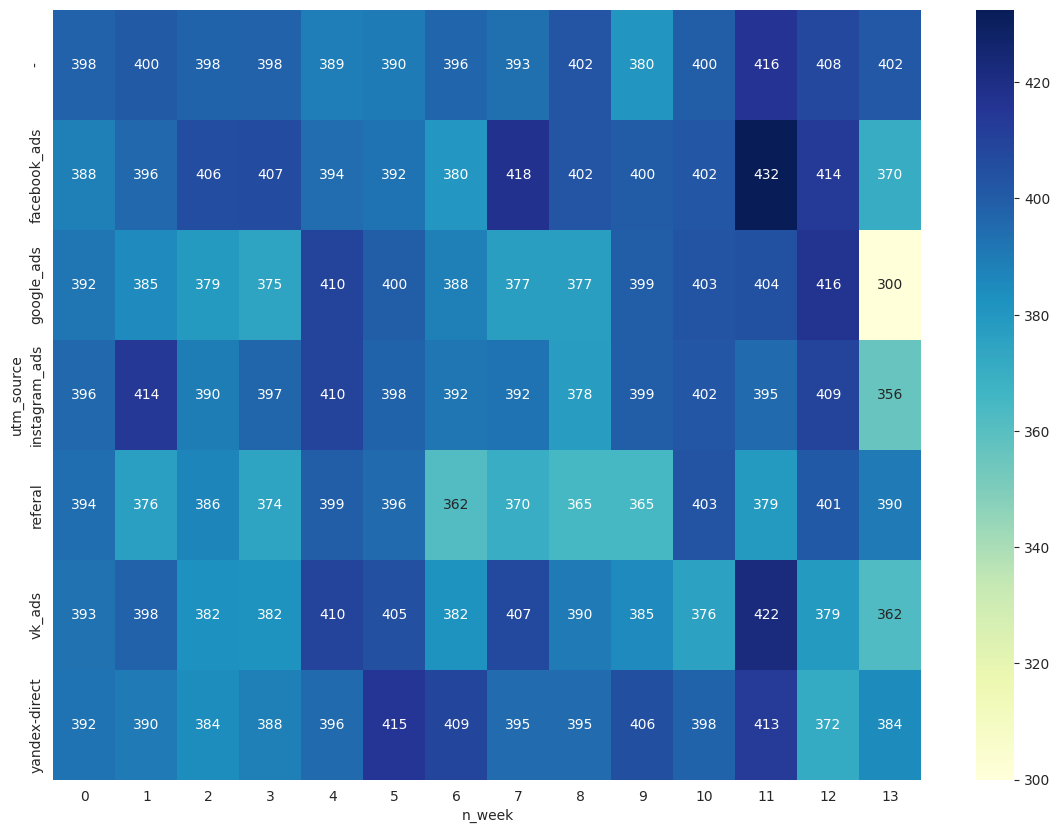

In [48]:
viz = df.pivot_table(
                        index='utm_source', 
                        columns='n_week', 
                        values='purchase_sum', 
                        aggfunc=np.median)
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(14, 10))
    ax = sns.heatmap(viz, annot=True, fmt=".0f", cmap="YlGnBu");

На второй неделе медианный чек выше у Инстаграм